In [1]:
import os
os.environ['OMP_NUM_THREADS']      = '1'
os.environ['MKL_NUM_THREADS']      = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'

In [2]:
# Imports
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import pickle
import sys
sys.path.append('../..')
sys.path.append('../../results')

from utils import W_from_J, init_cond, f as _f
from fig2.fig2_functions import classify_all
from fig7.new_orbits_functions import (
    make_many_biases, find_fixed_points,
    jacobians_for_all_fixed_points,
    f_inv_shifted_sigmoid, bias_for_fixed_point,
    jacobian_at_r, spectral_abscissa,
    pick_s_matched_distance, abscissa_curve_between
)

In [3]:
data_root = '../../data/fig2'

with open(f'{data_root}/sigma1/Ws.pkl', 'rb') as f:
    data2 = pickle.load(f)

solutions2  = [d for d in data2 if not np.all(d.get('W') == 0)]
matrices2   = [d['W'] for d in solutions2]
behaviours2 = np.load(f'{data_root}/behaviours/behaviours2.npy', allow_pickle=True).tolist()

classified         = classify_all(matrices2, [], [], behaviours2, [], [])
mat2_without_chaos = [matrices2[i] for i in classified[0]['idx_without_chaos']]

N    = 100
T    = 20
dt   = 0.005
tauE = 0.1
tauI = 0.1
a = np.ones(N); c = np.ones(N); b = np.zeros(N)

J = mat2_without_chaos[0]
W, _ = W_from_J(J, a, b, c)
initial_conditions = init_cond(J)

In [4]:
# Generate biased fixed points (same parameters as other fig7 notebooks)
# betas/epsilons/seeds were tuned to produce stable, well-separated fixed points
betas    = [-0.9, -0.7, 0.7, 0.7]
epsilons = [0.5,   0.2,  1.0, 0.3]
seeds    = [10,    19,   38,  7  ]

biases, etas = make_many_biases(N, betas, epsilons, seeds=seeds)

# Use f(bias) as the initial guess — near the fixed point by construction
r0s = np.vstack([_f(biases[:, k], a, b, c) for k in range(biases.shape[1])]).T

r_stars, ok, info = find_fixed_points(W, biases, r0s, alpha=0.001, every=5000)
print('ok:', ok, 'iters:', info['iters'], '||F||:', info['residual'])

Js, ds, zs = jacobians_for_all_fixed_points(W, biases, r_stars)
max_real = np.array([np.max(np.linalg.eigvals(Js[:,:,i]).real)
                     for i in range(Js.shape[2])])
print('max Re(eig):', max_real)

# Prepend the baseline (no-bias) Jacobian J as index 0
Js      = np.dstack((J, Js))
r_stars = np.column_stack((np.zeros(N), r_stars))
biases  = np.column_stack((np.zeros(N), biases))

k=0/4  ok=True  iters=112952  resid=9.991e-11
ok: [ True  True  True  True] iters: [112952 209402 111692  86990] ||F||: [9.99122679e-11 9.99586769e-11 9.99847665e-11 9.99554850e-11]
max Re(eig): [0.79970735 0.88983333 0.80313987 0.7201956 ]


In [5]:
# Compute spectral abscissa along two paths from r0 to r1
#
# Heterogeneous path: r0 -> r1
#   The actual biased fixed point; structured by the connectivity W
#   and the bias distribution.
#
# Homogeneous path: r0 -> s*1
#   A scalar-uniform point at the same Euclidean distance as r1.
#   Serves as a null model: what would happen if all neurons shifted equally?

r0 = r_stars[:, 0].copy()  # baseline fixed point (no bias)
r1 = r_stars[:, 1].copy()  # first biased fixed point

# Match the Euclidean distance of the homogeneous comparison point to r1
d_star     = np.linalg.norm(r1 - r0)
s_star     = pick_s_matched_distance(r0, d_star)
r_hom_star = s_star * np.ones_like(r0)

# Sweep spectral abscissa along each path (200 interpolation steps)
d_het, a_het, b_het, rcs_het, Jcs_het = abscissa_curve_between(W, r0, r1,         n=200)
d_hom, a_hom, b_hom, rcs_hom, Jcs_hom = abscissa_curve_between(W, r0, r_hom_star, n=200)

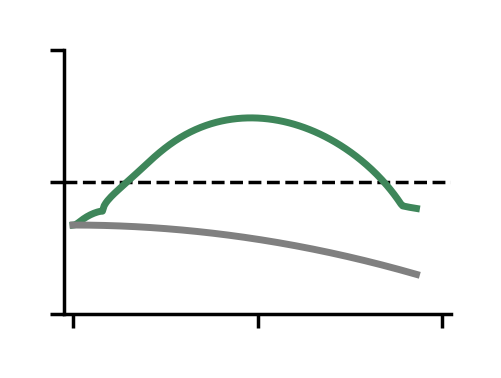

In [6]:
# Plot spectral abscissa vs distance from baseline
# Green: heterogeneous path (structured, bias-driven)
# Gray:  homogeneous path (unstructured, scalar control)
# The dashed line marks the stability boundary (abscissa = 0)

fig, ax = plt.subplots(figsize=(1, 0.7), dpi=500)
ax.axhline(0, linewidth=0.5, color='k', linestyle='--')
ax.plot(d_het, a_het, linewidth=1, color='#3e865a', label='heterogeneous')
ax.plot(d_hom, a_hom, linewidth=1, color='#808080', label='homogeneous')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
ax.tick_params(width=0.5, pad=1, length=2)
ax.set_xticks([0, 2, 4]);  ax.set_xticklabels(['', '', ''])
ax.set_yticks([-1, 0, 1]); ax.set_yticklabels(['', '', ''])
ax.set_xlim(-0.1, 4.1)
plt.show()